# SkinTell — 02 Preprocessing
Prepare data: copy images into a clean structure, apply augmentation, split into train/val sets.

In [3]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Paths
RAW_DIR = '../data/raw/acne_1024'
CLEAN_DIR  = '../data/processed'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Class configuration
CLASS_FOLDERS = ['acne0_1024', 'acne1_1024', 'acne2_1024', 'acne3_1024']
CLASS_LABELS  = ['clear', 'mild', 'moderate', 'severe']

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 1. Reorganize into Clean Folder Structure
Copy images from ACNE04 folders into a clean structure with human-readable class names.

In [4]:
# Build clean directory: data/processed/clear/, mild/, moderate/, severe/
for label in CLASS_LABELS:
    os.makedirs(os.path.join(CLEAN_DIR, label), exist_ok=True)

for folder, label in zip(CLASS_FOLDERS, CLASS_LABELS):
    src = os.path.join(RAW_DIR, folder)
    dst = os.path.join(CLEAN_DIR, label)
    images = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img in images:
        shutil.copy2(os.path.join(src, img), os.path.join(dst, img))
    print(f'  {folder} → {label}: {len(images)} images copied')

  acne0_1024 → clear: 483 images copied
  acne1_1024 → mild: 623 images copied
  acne2_1024 → moderate: 175 images copied
  acne3_1024 → severe: 96 images copied


## 2. Create Data Generators with Augmentation

In [5]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    CLEAN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    CLEAN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print(f'Class indices: {train_gen.class_indices}')
print(f'Training samples: {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

Found 1103 images belonging to 4 classes.
Found 274 images belonging to 4 classes.
Class indices: {'clear': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
Training samples: 1103
Validation samples: 274


## 3. Compute Class Weights (handle imbalance)

In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

print('Class weights (higher = rarer class gets more attention):')
for i, (label, weight) in enumerate(zip(CLASS_LABELS, class_weights)):
    print(f'  {label}: {weight:.3f}')

Class weights (higher = rarer class gets more attention):
  clear: 0.713
  mild: 0.553
  moderate: 1.970
  severe: 3.581


## 4. Visualize Augmented Samples

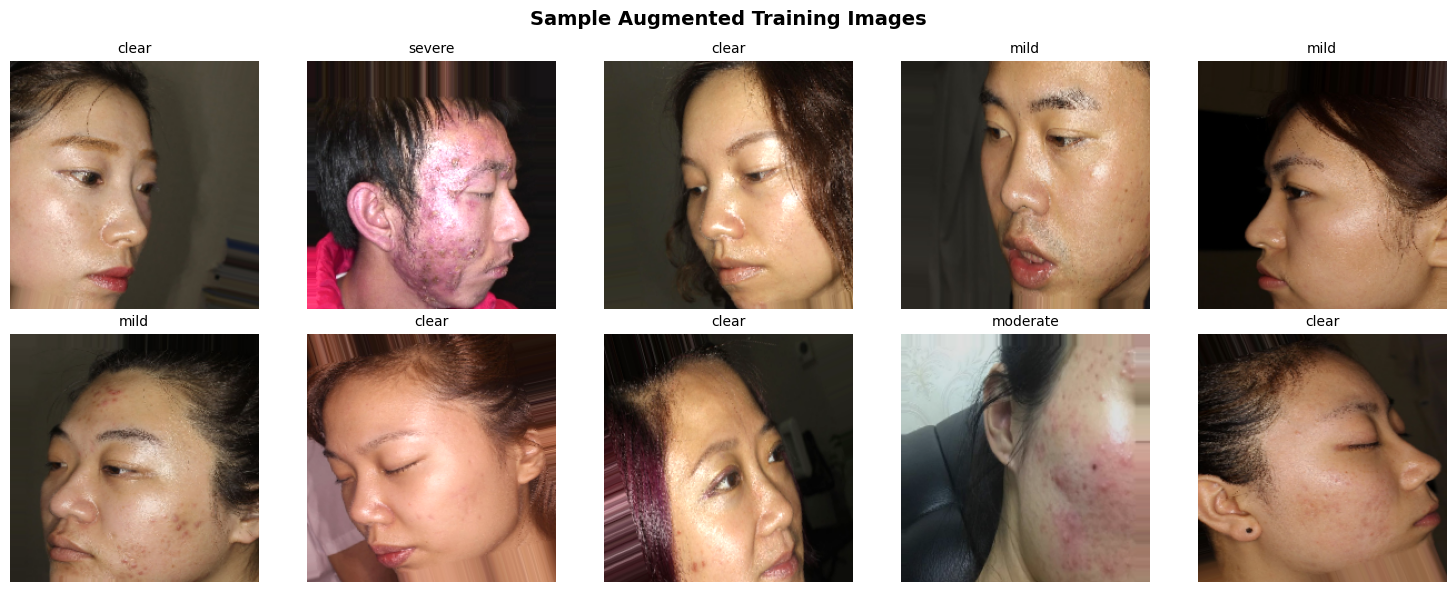

In [7]:
images, labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../plots/augmented_samples.png', dpi=150)
plt.show()